# 2. Core concepts in machine learning and/or network science. (25 points).

## Create a [flashcard](https://aiflashcards.com/) for the difficult concept you just walked us through. Use `matplotlib`, LaTeX, and any other illustrative techniques that are appropriate. *_[Potential 5 bonus points if this is made entirely in Python (e.g., Matplotlib, etc.).]_*

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import math
from matplotlib import cm
from matplotlib import colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.font_manager import FontProperties
import matplotlib.patheffects as pe

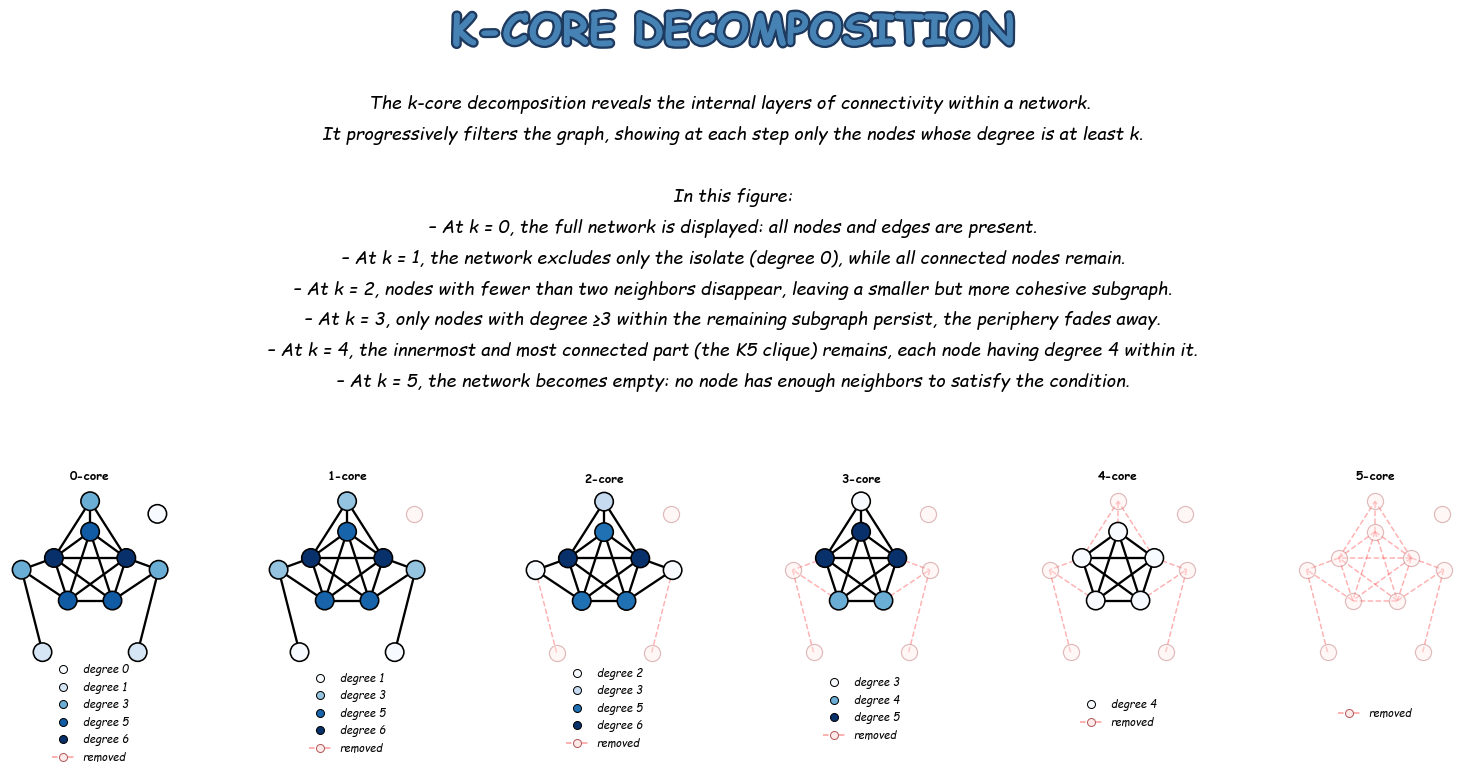

In [2]:
hand_font_name = "Comic Sans MS"  # oppure "Bradley Hand", "Lucida Handwriting"
legend_fp = FontProperties(family=hand_font_name, style="italic", size=11)
title_fp  = FontProperties(family=hand_font_name, weight="bold")

# ---------- HELPERS ----------
def polar(r, deg):
    t = math.radians(deg)
    return (r * math.cos(t), r * math.sin(t))

def draw_k(ax, G, k, pos, legend_y):
    ax.axis("off")
    ax.set_aspect("equal", adjustable="box")

    # === k-core corrente ===
    H = nx.k_core(G, k=k) if k > 0 else G

    # --- NODI E ARCHI RIMOSSI ---
    removed_nodes = set(G.nodes()) - set(H.nodes())
    removed_edges = [e for e in G.edges() if e[0] in removed_nodes or e[1] in removed_nodes]

    if removed_edges:
        nx.draw_networkx_edges(
            G.edge_subgraph(removed_edges), pos, ax=ax,
            alpha=0.3, style="dashed", edge_color="red", width=1.5
        )
    if removed_nodes:
        nx.draw_networkx_nodes(
            G.subgraph(removed_nodes), pos, ax=ax,
            node_size=260, node_color="#ffeaea",
            edgecolors="#b35a5a", linewidths=1.2, alpha=0.4
        )

    # --- NODI ATTIVI ---
    legend_handles = []
    if len(H) > 0:
        degH = dict(H.degree())
        vals = list(degH.values())
        vmin, vmax = min(vals), max(vals)
        if vmax == vmin:
            vmax = vmin + 1.0
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = cm.Blues
        node_colors = [cmap(norm(degH[n])) for n in H.nodes()]

        nx.draw_networkx_edges(H, pos, ax=ax, width=2.3, edge_color="black")
        nx.draw_networkx_nodes(
            H, pos, ax=ax,
            node_size=340, node_color=node_colors,
            edgecolors="black", linewidths=1.6
        )

        for d in sorted(set(vals)):
            color = cmap(norm(d))
            legend_handles.append(
                Line2D([], [], marker="o", linestyle="None", markersize=8,
                       markerfacecolor=color, markeredgecolor="black",
                       label=f"degree {d}")
            )

    legend_handles.append(
        Line2D([], [], marker="o", linestyle="--", color="#ff9999",
               markersize=8, markerfacecolor="#ffeaea",
               markeredgecolor="#b35a5a", label="removed")
    )

    # Legenda allineata verticalmente
    ax.legend(
        handles=legend_handles,
        loc="center",
        bbox_to_anchor=(0.5, legend_y),
        ncol=1,
        frameon=False,
        prop=legend_fp,
    )

    ax.set_title(f"{k}-core", fontweight="bold", pad=6, fontname=hand_font_name)

# ---------- COSTRUZIONE RETE ----------
r_core, r_mid, r_out = 1.0, 1.8, 2.5
G, pos = nx.Graph(), {}
core = [f"C{i}" for i in range(1, 6)]
angles_core = [90, 18, -54, -126, 162]
for n, ang in zip(core, angles_core):
    pos[n] = polar(r_core, ang)
for i in range(len(core)):
    for j in range(i + 1, len(core)):
        G.add_edge(core[i], core[j])

n3 = "S3"; pos[n3] = polar(r_mid, 90)
G.add_edges_from([(n3, core[0]), (n3, core[1]), (n3, core[4])])

n2L, n2R = "S2L", "S2R"
pos[n2L], pos[n2R] = polar(r_mid, 180), polar(r_mid, 0)
G.add_edges_from([(n2L, core[4]), (n2L, core[3])])
G.add_edges_from([(n2R, core[1]), (n2R, core[2])])

lL, lR = "L_left", "L_right"
pos[lL], pos[lR] = polar(r_out, 240), polar(r_out, 300)
G.add_edge(lL, n2L); G.add_edge(lR, n2R)

iso = "I1"; x, y = polar(r_out, 45); pos[iso] = (x, y - 0.3); G.add_node(iso)

# ---------- RENDERING ----------
fig = plt.figure(figsize=(26, 14))
gs  = gridspec.GridSpec(
    nrows=4, ncols=6, figure=fig,
    height_ratios=[0.8, 3.2, 0.6, 8.0],  # titolo più basso
    hspace=0.35, wspace=0.55
)

# Titolo in tonalità di blu sobria
ax_title = fig.add_subplot(gs[0, :]); ax_title.axis("off")
title_text = "K-CORE DECOMPOSITION"
ax_title.text(
    0.5, 0.30, title_text,
    ha="center", va="center",
    fontsize=42, color="#4682B4",  # steel blue
    fontproperties=title_fp,
    path_effects=[
        pe.withStroke(linewidth=5, foreground="#1E3A5F"),  # bordo navy
        pe.SimpleLineShadow(offset=(2.5, -2.5), shadow_color="#1E3A5F", alpha=0.45),
        pe.Normal(),
    ]
)

# Testo descrittivo
ax_text = fig.add_subplot(gs[1, :]); ax_text.axis("off")
explanation = (
    "The k-core decomposition reveals the internal layers of connectivity within a network. \n"
    "It progressively filters the graph, showing at each step only the nodes whose degree is at least k.\n\n"
    "In this figure:\n"
    "– At k = 0, the full network is displayed: all nodes and edges are present.\n"
    "– At k = 1, the network excludes only the isolate (degree 0), while all connected nodes remain.\n"
    "– At k = 2, nodes with fewer than two neighbors disappear, leaving a smaller but more cohesive subgraph.\n"
    "– At k = 3, only nodes with degree ≥3 within the remaining subgraph persist, the periphery fades away.\n"
    "– At k = 4, the innermost and most connected part (the K5 clique) remains, each node having degree 4 within it.\n"
    "– At k = 5, the network becomes empty: no node has enough neighbors to satisfy the condition.\n\n"
)
ax_text.text(
    0.5, 1.02, explanation,
    ha="center", va="top",
    fontsize=18, fontname=hand_font_name, style="italic",
    wrap=True, linespacing=1.85
)

# Spacer
fig.add_subplot(gs[2, :]).axis("off")

# Reti (legende allineate)
legend_y = -0.25
axes = [fig.add_subplot(gs[3, j]) for j in range(6)]
for k, ax in zip([0, 1, 2, 3, 4, 5], axes):
    draw_k(ax, G, k, pos, legend_y)

plt.show()

# 3. Random walk dynamics. (15 points).

## In *class 16*, we introduced the concept of the mean *first-passage time* of random walkers on a graph. Using  [Masuda, N., Porter, M. A., & Lambiotte, R. (2017). *Random walks and diffusion on networks. Physics Reports, 716*, 1–58 (https://www.sciencedirect.com/science/article/pii/S0370157317302946?via%3Dihub) as your guide:

## (a) Write a function from scratch that computes the *commute time* of a single random walker between nodes \(i\) and \(j\) in a network. Test this on the `karate_club` graph by printing the commute time between three randomly selected pairs of nodes.

In [8]:
def first_passage_time(G, start, target, rng, max_steps=100_000):
    """
    Simulate a single random walker on graph G and return the first-passage time
    from 'start' to 'target'.

    The walker:
    - starts at node 'start'
    - at each step, moves to a uniformly random neighbor
    - stops when it reaches 'target'

    Parameters
    ----------
    G : networkx.Graph
        The input graph (assumed connected).
    start : node
        Starting node.
    target : node
        Target node to be hit for the first time.
    rng : np.random.Generator
        Numpy random number generator instance.
    max_steps : int
        Safety cap on the number of steps in case something goes wrong.

    Returns
    -------
    int
        Number of steps taken to hit 'target' for the first time.
    """
    if start == target:
        return 0

    current = start
    steps = 0

    while current != target and steps < max_steps:
        neighbors = list(G.neighbors(current))
        if not neighbors:
            # Isolated node (should not happen in karate_club_graph)
            break
        current = rng.choice(neighbors)
        steps += 1

    return steps


def commute_time(G, i, j, num_trials=1000, seed=42):
    """
    Estimate the commute time between nodes i and j in graph G
    using Monte Carlo simulations of a single random walker.

    Commute time C_ij is defined as:
        C_ij = T_ij + T_ji
    where T_ij is the mean first-passage time from i to j.

    Parameters
    ----------
    G : networkx.Graph
        The input graph.
    i, j : nodes
        The two nodes between which we compute the commute time.
    num_trials : int
        Number of independent random-walk trials to average over.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    float
        Estimated commute time between i and j.
    """
    rng = np.random.default_rng(seed)

    total_T_ij = 0
    total_T_ji = 0

    for _ in range(num_trials):
        t_ij = first_passage_time(G, i, j, rng)
        t_ji = first_passage_time(G, j, i, rng)
        total_T_ij += t_ij
        total_T_ji += t_ji

    C_ij = (total_T_ij + total_T_ji) / num_trials
    return C_ij

In [11]:
# Load the Karate Club graph
G = nx.karate_club_graph()
nodes = list(G.nodes())

rng_global = np.random.default_rng(seed=123)

num_trials = 1000       # number of walks per estimate
n_repetitions = 100     # number of independent estimates of C_ij

print("Commute times for three random pairs of nodes in the Karate Club graph:\n")

for pair_idx in range(3):
    # Pick two distinct nodes at random
    i, j = rng_global.choice(nodes, size=2, replace=False)

    commute_estimates = []

    for _ in range(n_repetitions):
        # Different seed for each estimate to avoid identical runs
        seed = int(rng_global.integers(0, 1_000_000))
        C_ij = commute_time(G, i, j, num_trials=num_trials, seed=seed)
        commute_estimates.append(C_ij)

    commute_estimates = np.array(commute_estimates)
    mean_C = commute_estimates.mean()
    std_C = commute_estimates.std(ddof=1)

    print(
        f"Pair {pair_idx+1}: nodes i={i}, j={j} -> "
        f"mean commute time ≈ {mean_C:.2f}, std ≈ {std_C:.2f} "
        f"(based on {n_repetitions} estimates, each with num_trials={num_trials})"
    )

Commute times for three random pairs of nodes in the Karate Club graph:

Pair 1: nodes i=0, j=23 -> mean commute time ≈ 71.77, std ≈ 1.41 (based on 100 estimates, each with num_trials=1000)
Pair 2: nodes i=12, j=8 -> mean commute time ≈ 128.39, std ≈ 3.27 (based on 100 estimates, each with num_trials=1000)
Pair 3: nodes i=2, j=5 -> mean commute time ≈ 100.37, std ≈ 2.57 (based on 100 estimates, each with num_trials=1000)


## (b) Calculate the *mean* commute time between pairs of nodes in Erdős–Rényi networks with $N=500$ and $⟨k⟩=8$ and Barabási–Albert networks with $N=500$ and $m=4$. Compute the average commute time across all nodes in the network, then average this value across $10$ samples from each of these two graph models. Comment on any differences you observe.

In [12]:
def commute_time_matrix(G):
    """
    Compute the full matrix of commute times C_ij for an undirected, connected graph G
    using the Laplacian pseudoinverse:

        C_ij = 2m * (L^+_ii + L^+_jj - 2 L^+_ij)

    where m is the number of edges and L^+ is the Moore–Penrose pseudoinverse of the
    combinatorial Laplacian L.

    Parameters
    ----------
    G : networkx.Graph
        Undirected, connected graph.

    Returns
    -------
    C : np.ndarray, shape (N, N)
        Matrix of commute times, where C[i, j] is the commute time between nodes i and j.
        The node ordering is the one given by `list(G.nodes())`.
    """
    # Laplacian matrix
    L = nx.laplacian_matrix(G).toarray().astype(float)

    # Moore–Penrose pseudoinverse
    L_pinv = np.linalg.pinv(L)

    m = G.number_of_edges()
    vol = 2 * m  # sum of degrees

    # Diagonal of L^+
    diag_Lp = np.diag(L_pinv)

    # Use broadcasting to build C_ij = vol * (L^+_ii + L^+_jj - 2 L^+_ij)
    C = vol * (diag_Lp[:, None] + diag_Lp[None, :] - 2 * L_pinv)

    return C


def mean_commute_time_all_pairs(G):
    """
    Compute the mean commute time over all unordered node pairs (i < j) in G
    using the exact formula based on the Laplacian pseudoinverse.

    Parameters
    ----------
    G : networkx.Graph

    Returns
    -------
    float
        Mean commute time over all node pairs.
    """
    C = commute_time_matrix(G)
    n = C.shape[0]

    # Take only the upper triangle (i < j), excluding the diagonal
    iu, ju = np.triu_indices(n, k=1)
    return float(C[iu, ju].mean())

In [13]:
N = 500
k_avg = 8
m = 4
num_graphs = 10

rng = np.random.default_rng(123)

er_means = []
ba_means = []

# Erdős–Rényi: p such that <k> = p (N-1) = 8
p = k_avg / (N - 1)

# ----- ER graphs -----
for g_idx in range(num_graphs):
    seed_g = int(rng.integers(0, 1_000_000_000))
    G_er = nx.erdos_renyi_graph(N, p, seed=seed_g)

    # Make sure the graph is connected (rarely a problem at this density, but be safe)
    if not nx.is_connected(G_er):
        # Take the largest connected component
        G_er = G_er.subgraph(max(nx.connected_components(G_er), key=len)).copy()

    mean_C_er = mean_commute_time_all_pairs(G_er)
    er_means.append(mean_C_er)
    print(f"[ER] Graph {g_idx+1}/{num_graphs}: mean commute time ≈ {mean_C_er:.2f}")

# ----- BA graphs -----
for g_idx in range(num_graphs):
    seed_g = int(rng.integers(0, 1_000_000_000))
    G_ba = nx.barabasi_albert_graph(N, m, seed=seed_g)

    # BA is connected by construction, but we could still check if we want
    mean_C_ba = mean_commute_time_all_pairs(G_ba)
    ba_means.append(mean_C_ba)
    print(f"[BA] Graph {g_idx+1}/{num_graphs}: mean commute time ≈ {mean_C_ba:.2f}")

er_means = np.array(er_means)
ba_means = np.array(ba_means)

print("\n--- Summary over 10 samples ---")
print(f"ER  (N={N}, <k>={k_avg}): mean ≈ {er_means.mean():.2f}, std ≈ {er_means.std(ddof=1):.2f}")
print(f"BA  (N={N}, m={m})     : mean ≈ {ba_means.mean():.2f}, std ≈ {ba_means.std(ddof=1):.2f}")

[ER] Graph 1/10: mean commute time ≈ 1359.99
[ER] Graph 2/10: mean commute time ≈ 1294.09
[ER] Graph 3/10: mean commute time ≈ 1367.23
[ER] Graph 4/10: mean commute time ≈ 1382.73
[ER] Graph 5/10: mean commute time ≈ 1369.19
[ER] Graph 6/10: mean commute time ≈ 1348.11
[ER] Graph 7/10: mean commute time ≈ 1321.49
[ER] Graph 8/10: mean commute time ≈ 1358.64
[ER] Graph 9/10: mean commute time ≈ 1360.63
[ER] Graph 10/10: mean commute time ≈ 1336.63
[BA] Graph 1/10: mean commute time ≈ 1590.09
[BA] Graph 2/10: mean commute time ≈ 1578.84
[BA] Graph 3/10: mean commute time ≈ 1580.69
[BA] Graph 4/10: mean commute time ≈ 1578.62
[BA] Graph 5/10: mean commute time ≈ 1570.13
[BA] Graph 6/10: mean commute time ≈ 1573.79
[BA] Graph 7/10: mean commute time ≈ 1579.26
[BA] Graph 8/10: mean commute time ≈ 1578.14
[BA] Graph 9/10: mean commute time ≈ 1588.17
[BA] Graph 10/10: mean commute time ≈ 1588.47

--- Summary over 10 samples ---
ER  (N=500, <k>=8): mean ≈ 1349.87, std ≈ 26.13
BA  (N=500, m=4) 

### check on the commute_time_matrix approach vs MC approach function

In [14]:
# ------------------ Random-walk functions (Monte Carlo) ------------------
def first_passage_time(G, start, target, rng, max_steps=100_000):
    """
    Simulate a single random walker on graph G and return the first-passage time
    from 'start' to 'target'.
    """
    if start == target:
        return 0

    current = start
    steps = 0

    while current != target and steps < max_steps:
        neighbors = list(G.neighbors(current))
        if not neighbors:
            # Isolated node (should not happen in a connected graph)
            break
        current = rng.choice(neighbors)
        steps += 1

    return steps


def commute_time(G, i, j, num_trials=20_000, seed=42):
    """
    Estimate the commute time between nodes i and j in graph G
    using Monte Carlo simulations of a single random walker.

    Commute time C_ij is defined as:
        C_ij = T_ij + T_ji
    where T_ij is the mean first-passage time from i to j.
    """
    rng = np.random.default_rng(seed)

    total_T_ij = 0
    total_T_ji = 0

    for _ in range(num_trials):
        t_ij = first_passage_time(G, i, j, rng)
        t_ji = first_passage_time(G, j, i, rng)
        total_T_ij += t_ij
        total_T_ji += t_ji

    C_ij = (total_T_ij + total_T_ji) / num_trials
    return C_ij


# ------------------ Commute time via Laplacian pseudoinverse ------------------
def commute_time_matrix(G):
    """
    Compute the full matrix of commute times C_ij for an undirected, connected graph G
    using the Laplacian pseudoinverse:

        C_ij = 2m * (L^+_ii + L^+_jj - 2 L^+_ij)

    where m is the number of edges and L^+ is the Moore–Penrose pseudoinverse
    of the combinatorial Laplacian L.
    """
    # Laplacian matrix
    L = nx.laplacian_matrix(G).toarray().astype(float)

    # Moore–Penrose pseudoinverse
    L_pinv = np.linalg.pinv(L)

    m = G.number_of_edges()
    vol = 2 * m  # total sum of degrees

    # Diagonal of L^+
    diag_Lp = np.diag(L_pinv)

    # Broadcasting: C_ij = vol * (L^+_ii + L^+_jj - 2 L^+_ij)
    C = vol * (diag_Lp[:, None] + diag_Lp[None, :] - 2 * L_pinv)

    return C


# ------------------ Build a small test graph (for sanity check) ------------------
N = 50
k_avg = 8
p = k_avg / (N - 1)  # ER parameter

rng = np.random.default_rng(123)
G = nx.erdos_renyi_graph(N, p, seed=int(rng.integers(0, 1_000_000)))

# Ensure connectivity (should almost always be connected at this density, but just in case)
if not nx.is_connected(G):
    G = G.subgraph(max(nx.connected_components(G), key=len)).copy()

nodes = list(G.nodes())
n = len(nodes)

print(f"Sanity-check graph: N = {n}, edges = {G.number_of_edges()}")

# ------------------ Commute times from formula ------------------
C_formula = commute_time_matrix(G)

# Map nodes to indices to access C_formula
node_to_idx = {node: idx for idx, node in enumerate(nodes)}

# ------------------ Compare formula vs Monte Carlo on a few pairs ------------------
num_pairs_to_test = 5
num_trials_mc = 20_000  # number of Monte Carlo trials per pair

print(f"\nComparing commute time (formula vs Monte Carlo) on {num_pairs_to_test} random pairs:")
print(f"(Monte Carlo uses {num_trials_mc} trials per pair)\n")

for k in range(num_pairs_to_test):
    # sample two distinct nodes
    i, j = rng.choice(nodes, size=2, replace=False)
    idx_i = node_to_idx[i]
    idx_j = node_to_idx[j]

    C_theory = C_formula[idx_i, idx_j]

    # different seed per pair for MC
    seed_mc = int(rng.integers(0, 1_000_000_000))
    C_mc = commute_time(G, i, j, num_trials=num_trials_mc, seed=seed_mc)

    rel_error = abs(C_mc - C_theory) / C_theory

    print(f"Pair {k+1}: nodes (i={i}, j={j})")
    print(f"  Theoretical C_ij  = {C_theory:.2f}")
    print(f"  Monte Carlo C_ij  = {C_mc:.2f}")
    print(f"  Relative error    = {rel_error:.3%}\n")

Sanity-check graph: N = 50, edges = 204

Comparing commute time (formula vs Monte Carlo) on 5 random pairs:
(Monte Carlo uses 20000 trials per pair)

Pair 1: nodes (i=29, j=33)
  Theoretical C_ij  = 100.97
  Monte Carlo C_ij  = 101.22
  Relative error    = 0.251%

Pair 2: nodes (i=12, j=10)
  Theoretical C_ij  = 299.16
  Monte Carlo C_ij  = 299.35
  Relative error    = 0.063%

Pair 3: nodes (i=8, j=17)
  Theoretical C_ij  = 85.95
  Monte Carlo C_ij  = 86.26
  Relative error    = 0.365%

Pair 4: nodes (i=22, j=45)
  Theoretical C_ij  = 210.34
  Monte Carlo C_ij  = 210.60
  Relative error    = 0.119%

Pair 5: nodes (i=40, j=43)
  Theoretical C_ij  = 79.17
  Monte Carlo C_ij  = 79.72
  Relative error    = 0.689%

